In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Questio - 01

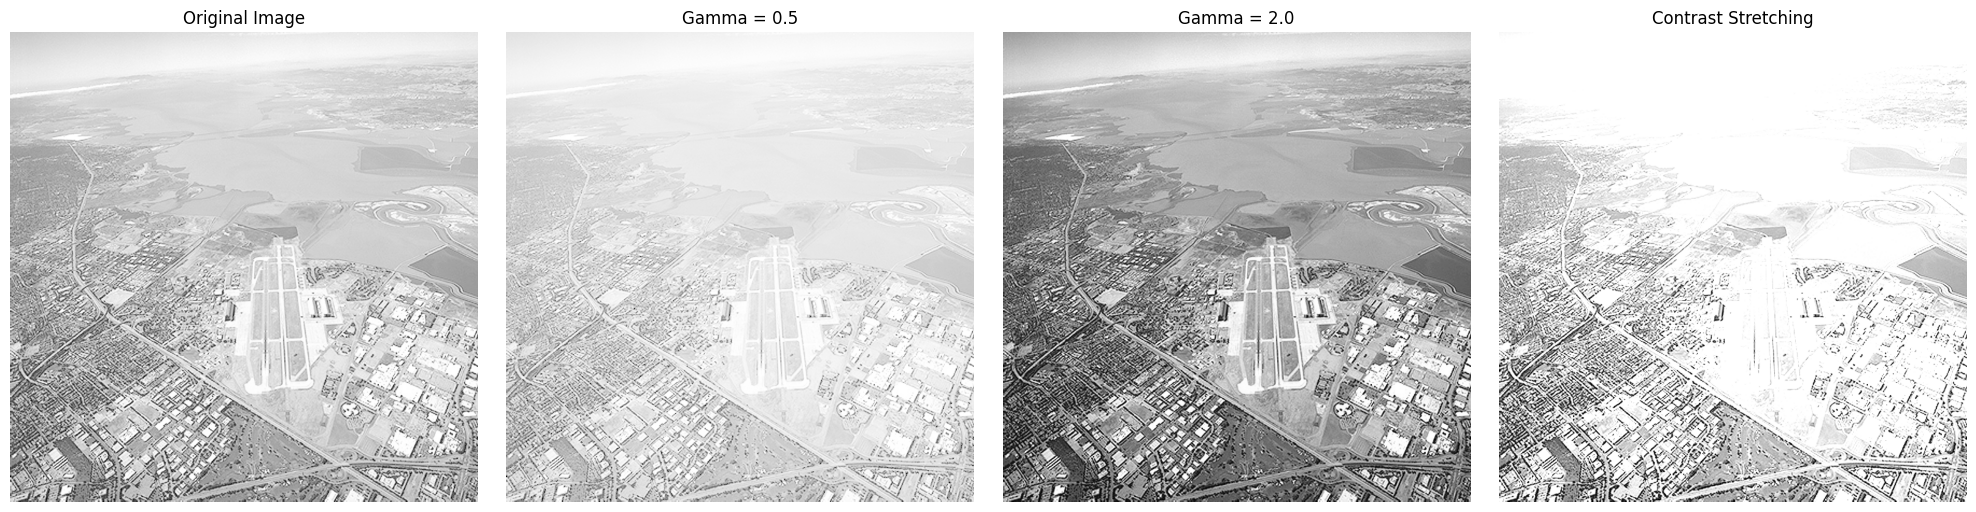

In [12]:
image_path = '../data/runway.png'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is not None:
    # Normalize input pixel intensity (r) to the range [0, 1] as requested
    r = img / 255.0

    # (a) Gamma correction with gamma = 0.5
    gamma_a = 0.5
    s_a = np.power(r, gamma_a)

    # (b) Gamma correction with gamma = 2
    gamma_b = 2.0
    s_b = np.power(r, gamma_b)

    # (c) Contrast Stretching (linear piecewise)
    r1, r2 = 0.2, 0.8
    s_c = np.zeros_like(r) # Initialize output array with zeros

    # Apply the piecewise mathematical conditions directly
    s_c[r < r1] = 0
    mask = (r >= r1) & (r <= r2) # Mid-range condition
    s_c[mask] = (r[mask] - r1) / (r2 - r1)
    s_c[r > r2] = 1

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(r, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(s_a, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Gamma = 0.5')
    axes[1].axis('off')

    axes[2].imshow(s_b, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title('Gamma = 2.0')
    axes[2].axis('off')

    axes[3].imshow(s_c, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title('Contrast Stretching')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    fig.savefig('../output/q1_results.png', bbox_inches='tight')

else:
    print(f"Error: Could not find image at {image_path}")


Question - 02

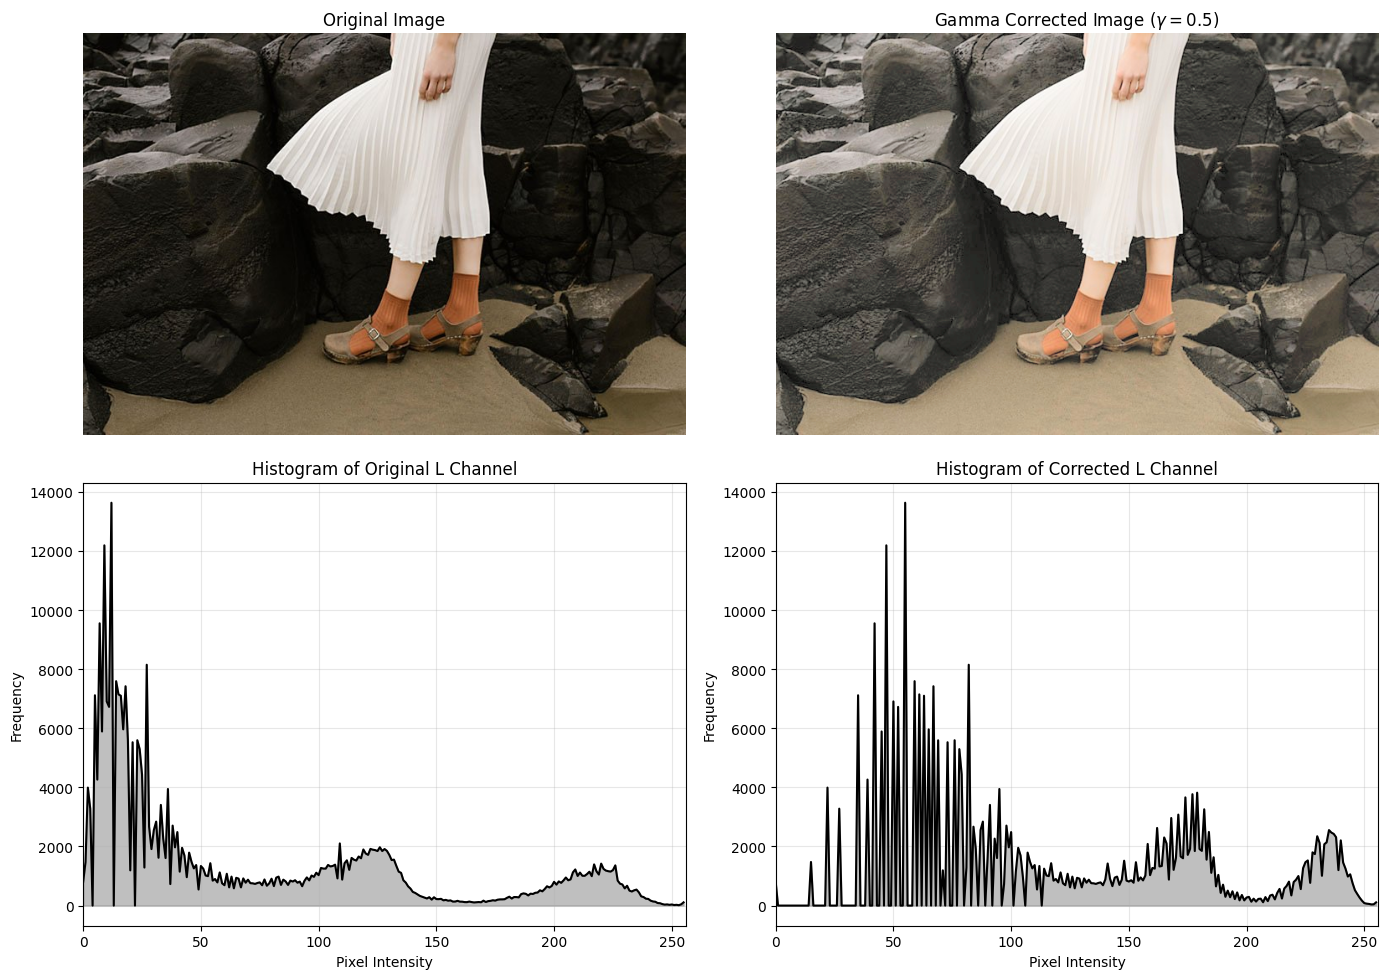

In [14]:
image_path_2 = '../data/highlights_and_shadows.jpg'
img_bgr = cv2.imread(image_path_2)

if img_bgr is not None:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # (a) Convert to L*a*b* and Apply Gamma Correction
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

    # Split into the L, a, and b channels
    l, a, b = cv2.split(img_lab)

    # Normalize the L channel to the range [0, 1] for mathematical operations
    l_norm = l / 255.0

    # Define the gamma value.
    # Since the image likely has heavy shadows based on its name,
    # a gamma < 1 will boost the darker midtones.
    gamma_val = 0.5

    # Apply the power-law transformation (Gamma Correction)
    l_corrected_norm = np.power(l_norm, gamma_val)

    # Scale back to [0, 255] and convert back to 8-bit unsigned integers
    l_corrected = np.clip(l_corrected_norm * 255.0, 0, 255).astype(np.uint8)

    # Merge the corrected L channel back with the untouched a and b color channels
    lab_corrected = cv2.merge((l_corrected, a, b))

    # Convert the assembled LAB image back to RGB for displaying
    img_corrected_rgb = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2RGB)

    # (b) Show Histograms
    # Calculate histograms for the original and corrected L channels
    # We use 256 bins for the 0-255 intensity range
    hist_orig = cv2.calcHist([l], [0], None, [256], [0, 256])
    hist_corr = cv2.calcHist([l_corrected], [0], None, [256], [0, 256])

    #  Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Original Image
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    # Plot 2: Corrected Image
    axes[0, 1].imshow(img_corrected_rgb)
    axes[0, 1].set_title(rf'Gamma Corrected Image ($\gamma={gamma_val}$)')
    axes[0, 1].axis('off')

    # Plot 3: Original Histogram
    axes[1, 0].plot(hist_orig, color='black')
    axes[1, 0].fill_between(np.arange(256), hist_orig.flatten(), color='gray', alpha=0.5)
    axes[1, 0].set_title('Histogram of Original L Channel')
    axes[1, 0].set_xlabel('Pixel Intensity')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_xlim([0, 256])
    axes[1, 0].grid(True, alpha=0.3)

    # Plot 4: Corrected Histogram
    axes[1, 1].plot(hist_corr, color='black')
    axes[1, 1].fill_between(np.arange(256), hist_corr.flatten(), color='gray', alpha=0.5)
    axes[1, 1].set_title('Histogram of Corrected L Channel')
    axes[1, 1].set_xlabel('Pixel Intensity')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_xlim([0, 256])
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    fig.savefig('../output/q2_results.png', bbox_inches='tight')
else:
    print(f"Error: Could not find image at {image_path_2}")